# Spine Ultrasound 2D segmentation 
## Medical Image Analysis - Final Project - by - Tracey Li

#### Step1: Setup imports

In [1]:
import os
import re
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import binary_erosion, distance_transform_edt
from tqdm import tqdm
import SimpleITK as sitk
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader
from monai.data import CacheDataset, decollate_batch, DataLoader
from monai.transforms import (
    Compose,
    MapTransform,
    EnsureChannelFirstd,
    ScaleIntensityd,
    Resized,
    EnsureTyped,
    LoadImaged
)
from monai.networks.nets import AttentionUnet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.networks.nets import UNet
from monai.networks.layers import Norm

#### Step2: Setup basic viriables and functions

In [2]:
##Block 2
DATA_ROOT = r"E:\CMU courses\2026 Spring\16725 Medical Image Analysis\final project\data\US_labeled\Extracted"   ##Sorry my ROOT is messy
OUTPUT_DIR = r"E:\CMU courses\2026 Spring\16725 Medical Image Analysis\final project\code\output\Unet_lr1e4_third_version"  
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_EPOCHS = 50  ##50 is enough according to the test
IMAGE_SIZE = (768,512)  ## I used the script"find the crop" to determine the crop size, then I Choose this number 768*512
VAL_RATIO = 0.2
ALLOWED_SCAN_PREFIXES = ["D","H","R","M"] ###R H M D means four kinds of scanning modes
MAX_SAMPLES = None
NUM_VIS_SAMPLES = 8
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("DEVICE =", DEVICE)

DEVICE = cuda


In [3]:
##Block 3 Define some functions I am going to use
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def read_mhd(path): # this function will return to label matrix
    img = sitk.ReadImage(path)
    arr = sitk.GetArrayFromImage(img) 
    if arr.ndim == 3 and arr.shape[0] == 1:
        arr = arr[0]
    arr = np.squeeze(arr)
    return arr

def binarize_mask(mask): # My label is 0 and 2(foreground), so I need to transit it to 0 and 1
    return (mask > mask.min()).astype(np.float32)

def extract_subject_id(path): # This function returns subject ID
    m = re.search(r"(URS\d+)", path)
    return m.group(1) if m else "UNKNOWN"

def extract_scan_group(path):  # This function returns scanning mode
    m = re.search(r"URS\d+_([HRDM])\d+", path)
    return m.group(1) if m else "UNKNOWN"

set_seed(SEED)

#### Step3: Construct dictionaries and Visualize all samples

In [4]:
##Block 4 Count samples!!
def discover_samples(data_root, allowed_scan_prefixes=None, max_samples=None):
    data_root = Path(data_root)
    label_paths = sorted(data_root.rglob("*-labels.mhd"))

    samples = []

    for label_path in label_paths:
        image_name = label_path.name.replace("-labels.mhd", ".mhd")
        image_path = label_path.with_name(image_name)

        if not image_path.exists():
            continue

        sample = {
            "image": str(image_path),
            "label": str(label_path),
            "subject_id": extract_subject_id(str(label_path)),
            "scan_group": extract_scan_group(str(label_path)),
        }
        if allowed_scan_prefixes is not None:
            if sample["scan_group"] not in allowed_scan_prefixes:
                continue

        samples.append(sample)

    if max_samples is not None:
        samples = samples[:max_samples]

    return samples

samples = discover_samples(
    DATA_ROOT,
    allowed_scan_prefixes=ALLOWED_SCAN_PREFIXES,
    max_samples=MAX_SAMPLES
)

print("Total sample number is =", len(samples))
print("First three samples are：")
for s in samples[:3]:
    print(s)

Total sample number is = 6182
First three samples are：
{'image': 'E:\\CMU courses\\2026 Spring\\16725 Medical Image Analysis\\final project\\data\\US_labeled\\Extracted\\URS08_H1\\URS08_H1\\Labels\\0.mhd', 'label': 'E:\\CMU courses\\2026 Spring\\16725 Medical Image Analysis\\final project\\data\\US_labeled\\Extracted\\URS08_H1\\URS08_H1\\Labels\\0-labels.mhd', 'subject_id': 'URS08', 'scan_group': 'H'}
{'image': 'E:\\CMU courses\\2026 Spring\\16725 Medical Image Analysis\\final project\\data\\US_labeled\\Extracted\\URS08_H1\\URS08_H1\\Labels\\1.mhd', 'label': 'E:\\CMU courses\\2026 Spring\\16725 Medical Image Analysis\\final project\\data\\US_labeled\\Extracted\\URS08_H1\\URS08_H1\\Labels\\1-labels.mhd', 'subject_id': 'URS08', 'scan_group': 'H'}
{'image': 'E:\\CMU courses\\2026 Spring\\16725 Medical Image Analysis\\final project\\data\\US_labeled\\Extracted\\URS08_H1\\URS08_H1\\Labels\\10.mhd', 'label': 'E:\\CMU courses\\2026 Spring\\16725 Medical Image Analysis\\final project\\data\\US

URS51 R


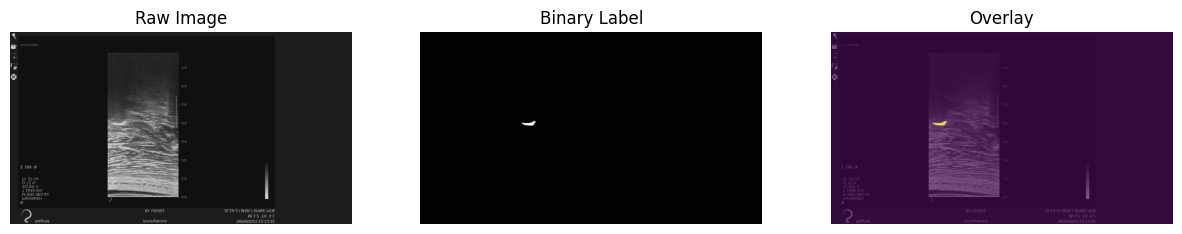

URS16 H


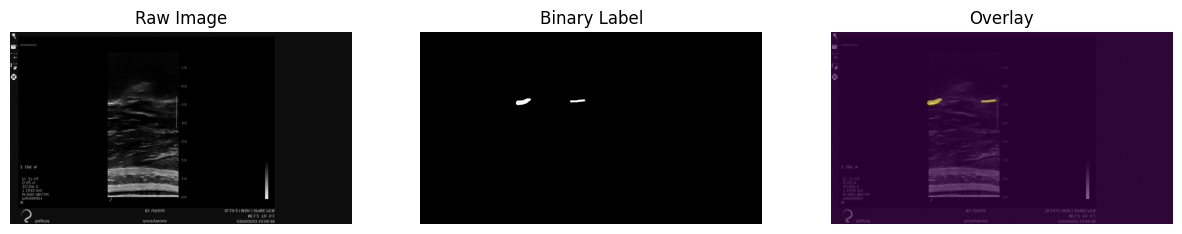

URS08 H


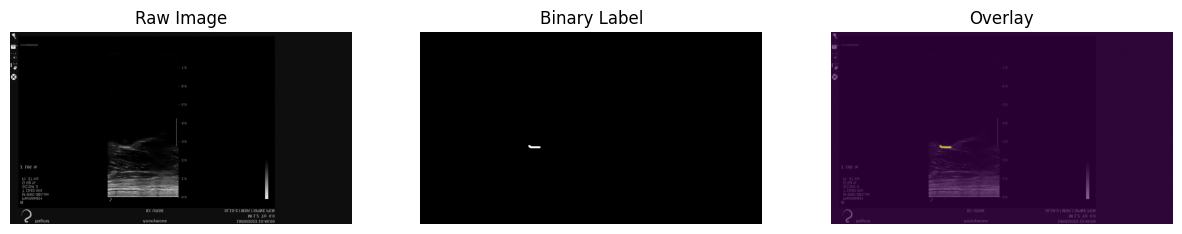

In [5]:
##Block 5 Visualize samples
def show_sample(sample):
    image = read_mhd(sample["image"])
    label = read_mhd(sample["label"])
    label_bi = binarize_mask(label)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image, cmap="gray")
    axes[0].set_title("Raw Image")
    axes[0].axis("off")

    axes[1].imshow(label_bi, cmap="gray")
    axes[1].set_title("Binary Label")
    axes[1].axis("off")

    axes[2].imshow(image, cmap="gray")
    axes[2].imshow(label_bi, alpha=0.6)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.show()

for s in random.sample(samples, min(3, len(samples))):
    print(s["subject_id"], s["scan_group"])
    show_sample(s)

#### Step4: Data preparation: Avoid Leakage & Cropping & 统一通道数

In [6]:
# Block 6 Avoid data leakage and train data/test data dividing
subjects = sorted(list(set([s["subject_id"] for s in samples])))

train_subjects, val_subjects = train_test_split(
    subjects,
    test_size=VAL_RATIO, ##VAL_RATIO=0.2
    random_state=SEED
)

train_files = []
for s in samples:
    if s["subject_id"] in train_subjects:
        train_files.append(s)
val_files = []
for s in samples:
    if s["subject_id"] in val_subjects:
        val_files.append(s)

print("subjects are:", subjects)
print("Train subjects:", train_subjects)
print("Val subjects:", val_subjects)
print("Train samples:", len(train_files))
print("Val samples:", len(val_files))

subjects are: ['URS08', 'URS16', 'URS26', 'URS31', 'URS36', 'URS40', 'URS45', 'URS51', 'URS54']
Train subjects: ['URS40', 'URS08', 'URS54', 'URS26', 'URS36', 'URS31', 'URS45']
Val subjects: ['URS51', 'URS16']
Train samples: 4850
Val samples: 1332


In [7]:
##Block 7: Updated version_taking URS31_D2 0.mhd into account
CROP_BOX = (76, 954, 501, 1008)
class LoadMHDd(MapTransform):
    def __init__(self, keys):
        super().__init__(keys)

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            arr = read_mhd(d[key])
            arr = np.asarray(arr)
            arr = np.squeeze(arr)

            if key == "image" and arr.ndim == 3:
                if arr.shape[-1] == 3:
                    arr = arr.mean(axis=-1)   
                elif arr.shape[0] == 3:
                    arr = arr.mean(axis=0)    

           
            if key == "label" and arr.ndim == 3:
                if arr.shape[-1] == 3:
                    arr = arr[..., 0]
                elif arr.shape[0] == 3:
                    arr = arr[0]

            
            if arr.ndim != 2:
                raise ValueError(f"{key} is not 2D: shape={arr.shape}, path={d[key]}")

            if key == "label":
                arr = binarize_mask(arr)

            arr = arr.astype(np.float32)
            
            if CROP_BOX is not None:
                y_min, y_max, x_min, x_max = CROP_BOX
                arr = arr[y_min:y_max, x_min:x_max]

            d[key] = arr

        return d
    

In [8]:
##test block  this block for testing, it seems that the URS31_D2 is not a grey scale file, instead it has three channels
loader_only = LoadMHDd(keys=["image", "label"])
bad_out = loader_only(train_files[1360])
print(bad_out["image"].shape)
print(bad_out["label"].shape)

(878, 507)
(878, 507)


#### Step5: Data Transform & Caching

In [9]:
##Block 8 
NUM_WORKERS = 2
BATCH_SIZE = 4
CACHE_RATE = 0.2   

train_transforms = Compose([
    LoadMHDd(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"], channel_dim="no_channel"),
    ScaleIntensityd(keys=["image"]),
    Resized(keys=["image"], spatial_size=IMAGE_SIZE, mode="bilinear"),
    Resized(keys=["label"], spatial_size=IMAGE_SIZE, mode="nearest"),
    EnsureTyped(keys=["image", "label"]),
])

val_transforms = Compose([
    LoadMHDd(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"], channel_dim="no_channel"),
    ScaleIntensityd(keys=["image"]),
    Resized(keys=["image"], spatial_size=IMAGE_SIZE, mode="bilinear"),
    Resized(keys=["label"], spatial_size=IMAGE_SIZE, mode="nearest"),
    EnsureTyped(keys=["image", "label"]),
])

train_ds = CacheDataset(
    data=train_files,
    transform=train_transforms,
    cache_rate=CACHE_RATE,
    num_workers=NUM_WORKERS,
)

val_ds = CacheDataset(
    data=val_files,
    transform=val_transforms,
    cache_rate=CACHE_RATE,
    num_workers=NUM_WORKERS,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print("train ds =", len(train_ds))
print("val ds =", len(val_ds))

Loading dataset: 100%|██████████| 266/266 [00:02<00:00, 124.47it/s]

train ds = 4850
val ds = 1332


In [10]:
##Block 9
batch = next(iter(train_loader))
print("image shape =", batch["image"].shape)
print("label shape =", batch["label"].shape)
print("dtype image =", batch["image"].dtype)
print("dtype label =", batch["label"].dtype)
print(train_ds[0]["image"].shape)
print(train_ds[0]["label"].shape)

image shape = torch.Size([4, 1, 768, 512])
label shape = torch.Size([4, 1, 768, 512])
dtype image = torch.float32
dtype label = torch.float32
torch.Size([1, 768, 512])
torch.Size([1, 768, 512])


#### Step6: Model define, here are 10.1 AttentionUnet models and 10.2 Unet

In [11]:
# ##Block 10.1 Define the model, optimizer and dice_metric
# LR = 1e-4
# WEIGHT_DECAY = 1e-4  ## 1e-5 is not enough, add up this to 1e-4
# model = AttentionUnet(
#     spatial_dims=2,
#     in_channels=1,
#     out_channels=1,
#     channels=(16, 32, 64, 128, 256),
#     strides=(2, 2, 2, 2),
#     dropout=0.2, ##adjusted from 0.1 to 0.2
# ).to(DEVICE)

# loss_function = DiceCELoss(sigmoid=True)

# optimizer = torch.optim.AdamW(
#     model.parameters(),
#     lr=LR,
#     weight_decay=WEIGHT_DECAY
# )

# dice_metric = DiceMetric(
#     include_background=True,
#     reduction="mean"
# )

# print(model)

In [12]:
# ##Block 10.2 Define the model, optimizer and dice_metric
LR = 1e-4
WEIGHT_DECAY = 1e-4  ## 1e-5 is not enough, add up this to 1e-4
model = UNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=3,
    dropout=0.5,  ##adjusted from 0 to 0.2 to 0.5
    norm=Norm.BATCH
).to(DEVICE)

loss_function = DiceCELoss(sigmoid=True)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

dice_metric = DiceMetric(
    include_background=True,
    reduction="mean"
)

print("Using model: UNet")
print(model)

Using model: UNet
UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (adn): ADN(
            (N): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.5, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (adn): ADN(
            (N): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.5, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit2): Convolution(
          (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (adn): ADN(
            (N): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_runnin

In [13]:
## Block 10.5 Define other metrics
def to_numpy_binary(mask):
    """
    输入:
        torch tensor 或 numpy array
    输出:
        0/1 numpy array
    """
    if hasattr(mask, "detach"):
        mask = mask.detach().cpu().numpy()
    mask = np.asarray(mask)
    mask = (mask > 0.5).astype(np.uint8)
    return mask


def compute_dice_np(pred, gt, eps=1e-8):
    pred = to_numpy_binary(pred)
    gt = to_numpy_binary(gt)

    intersection = (pred * gt).sum()
    return (2.0 * intersection + eps) / (pred.sum() + gt.sum() + eps)


def compute_iou_np(pred, gt, eps=1e-8):
    pred = to_numpy_binary(pred)
    gt = to_numpy_binary(gt)

    intersection = (pred * gt).sum()
    union = pred.sum() + gt.sum() - intersection
    return (intersection + eps) / (union + eps)


def compute_precision_recall_np(pred, gt, eps=1e-8):
    pred = to_numpy_binary(pred)
    gt = to_numpy_binary(gt)

    tp = ((pred == 1) & (gt == 1)).sum()
    fp = ((pred == 1) & (gt == 0)).sum()
    fn = ((pred == 0) & (gt == 1)).sum()

    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    return precision, recall


def get_boundary(mask):
    mask = to_numpy_binary(mask)
    if mask.sum() == 0:
        return mask
    eroded = binary_erosion(mask)
    boundary = mask - eroded
    return boundary.astype(np.uint8)


def surface_distances(pred, gt):
   
    pred = to_numpy_binary(pred)
    gt = to_numpy_binary(gt)

    pred_boundary = get_boundary(pred)
    gt_boundary = get_boundary(gt)

    if pred_boundary.sum() == 0 and gt_boundary.sum() == 0:
        return np.array([0.0]), np.array([0.0])

    if pred_boundary.sum() == 0 or gt_boundary.sum() == 0:
        return np.array([np.inf]), np.array([np.inf])

    dt_gt = distance_transform_edt(1 - gt_boundary)
    dt_pred = distance_transform_edt(1 - pred_boundary)

    pred_to_gt = dt_gt[pred_boundary == 1]
    gt_to_pred = dt_pred[gt_boundary == 1]

    return pred_to_gt, gt_to_pred


def compute_hd95_np(pred, gt):
    pred_to_gt, gt_to_pred = surface_distances(pred, gt)
    all_dists = np.concatenate([pred_to_gt, gt_to_pred])

    if np.isinf(all_dists).any():
        return np.inf

    return np.percentile(all_dists, 95)

def compute_hd100_np(pred, gt):
    pred_to_gt, gt_to_pred = surface_distances(pred, gt)
    all_dists = np.concatenate([pred_to_gt, gt_to_pred])

    if np.isinf(all_dists).any():
        return np.inf

    return np.percentile(all_dists, 100)


def compute_assd_np(pred, gt):
    pred_to_gt, gt_to_pred = surface_distances(pred, gt)

    if np.isinf(pred_to_gt).any() or np.isinf(gt_to_pred).any():
        return np.inf

    return (pred_to_gt.mean() + gt_to_pred.mean()) / 2.0


def compute_boundary_f1_np(pred, gt, tolerance=2):
    pred = to_numpy_binary(pred)
    gt = to_numpy_binary(gt)

    pred_boundary = get_boundary(pred)
    gt_boundary = get_boundary(gt)

    if pred_boundary.sum() == 0 and gt_boundary.sum() == 0:
        return 1.0
    if pred_boundary.sum() == 0 or gt_boundary.sum() == 0:
        return 0.0

    dt_gt = distance_transform_edt(1 - gt_boundary)
    dt_pred = distance_transform_edt(1 - pred_boundary)

    pred_match = (dt_gt[pred_boundary == 1] <= tolerance).sum()
    gt_match = (dt_pred[gt_boundary == 1] <= tolerance).sum()

    precision = pred_match / (pred_boundary.sum() + 1e-8)
    recall = gt_match / (gt_boundary.sum() + 1e-8)

    if precision + recall == 0:
        return 0.0

    return 2 * precision * recall / (precision + recall + 1e-8)

In [14]:
##Block 11 forward pass and output shape verification
images = batch["image"].to(DEVICE)
with torch.no_grad():
    outputs = model(images)
print("input :", images.shape)
print("output:", outputs.shape)

input : torch.Size([4, 1, 768, 512])
output: torch.Size([4, 1, 768, 512])


In [15]:
##Block 12 define training process & validation process
def train_one_epoch(model, loader, optimizer, loss_function, device):
    model.train()
    epoch_loss = 0

    for batch_data in tqdm(loader, desc="Train", leave=False):
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(loader)
    return epoch_loss


@torch.no_grad()
def val_one_epoch(model, loader, loss_function, dice_metric, device):
    model.eval()
    epoch_loss = 0

    dice_metric.reset()
    dice_list = []
    iou_list = []
    precision_list = []
    recall_list = []
    hd95_list = []
    hd100_list = []
    assd_list = []
    bf1_list = []

    for batch_data in tqdm(loader, desc="Val", leave=False):
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)

        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        epoch_loss += loss.item()

        preds = torch.sigmoid(outputs)
        preds = (preds > 0.5).float()

        pred_list = decollate_batch(preds)
        label_list = decollate_batch(labels)
        dice_metric(y_pred=pred_list, y=label_list)
        
        for p, g in zip(pred_list, label_list):
            p_np = p[0].cpu().numpy()
            g_np = g[0].cpu().numpy()

            dice_list.append(compute_dice_np(p_np, g_np))
            iou_list.append(compute_iou_np(p_np, g_np))

            precision, recall = compute_precision_recall_np(p_np, g_np)
            precision_list.append(precision)
            recall_list.append(recall)

            hd95_list.append(compute_hd95_np(p_np, g_np))
            hd100_list.append(compute_hd100_np(p_np, g_np))
            assd_list.append(compute_assd_np(p_np, g_np))
            bf1_list.append(compute_boundary_f1_np(p_np, g_np, tolerance=2))

    epoch_loss /= len(loader)
    metrics = {
        "dice": float(np.mean(dice_list)),
        "iou": float(np.mean(iou_list)),
        "precision": float(np.mean(precision_list)),
        "recall": float(np.mean(recall_list)),
        "hd95": float(np.mean([x for x in hd95_list if np.isfinite(x)])) if np.any(np.isfinite(hd95_list)) else np.inf,
        "hd100": float(np.mean([x for x in hd100_list if np.isfinite(x)])) if np.any(np.isfinite(hd95_list)) else np.inf,
        "assd": float(np.mean([x for x in assd_list if np.isfinite(x)])) if np.any(np.isfinite(assd_list)) else np.inf,
        "boundary_f1": float(np.mean(bf1_list)),
    }

    return epoch_loss, metrics

#### Step7: Model training and metrics calculation & saving

In [16]:
# Block 13
best_dice = -1
train_losses = []
val_losses = []
val_dices = []
val_ious = []
val_precisions = []
val_recalls = []
val_hd95s = []
val_hd100s = []
val_assds = []
val_bf1s = []

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_function, DEVICE)
    val_loss, val_metrics = val_one_epoch(model, val_loader, loss_function, dice_metric, DEVICE)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    val_dices.append(val_metrics["dice"])
    val_ious.append(val_metrics["iou"])
    val_precisions.append(val_metrics["precision"])
    val_recalls.append(val_metrics["recall"])
    val_hd95s.append(val_metrics["hd95"])
    val_hd100s.append(val_metrics["hd100"])
    val_assds.append(val_metrics["assd"])
    val_bf1s.append(val_metrics["boundary_f1"])

    print(
        f"Epoch [{epoch}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Dice: {val_metrics['dice']:.4f} | "
        f"IoU: {val_metrics['iou']:.4f} | "
        f"Precision: {val_metrics['precision']:.4f} | "
        f"Recall: {val_metrics['recall']:.4f} | "
        f"HD95: {val_metrics['hd95']:.4f} | "
        f"HD100: {val_metrics['hd100']:.4f} | "
        f"ASSD: {val_metrics['assd']:.4f} | "
        f"Boundary F1: {val_metrics['boundary_f1']:.4f}"
    )

    torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "last_model.pt"))

    if val_metrics["dice"] > best_dice:
        best_dice = val_metrics["dice"]
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "best_model.pt"))
        print("save the newest best model, best dice =", best_dice)


Epoch [1/50] | Train Loss: 1.5515 | Val Loss: 1.4742 | Dice: 0.0601 | IoU: 0.0601 | Precision: 1.0000 | Recall: 0.0601 | HD95: 0.0000 | HD100: 0.0000 | ASSD: 0.0000 | Boundary F1: 0.0601
save the newest best model, best dice = 0.06006006006833554


Epoch [2/50] | Train Loss: 1.4313 | Val Loss: 1.3657 | Dice: 0.0601 | IoU: 0.0601 | Precision: 0.9347 | Recall: 0.0601 | HD95: 181.8640 | HD100: 183.8418 | ASSD: 140.1468 | Boundary F1: 0.0601


Epoch [3/50] | Train Loss: 1.2818 | Val Loss: 1.1893 | Dice: 0.0601 | IoU: 0.0601 | Precision: 0.6854 | Recall: 0.0601 | HD95: 267.5414 | HD100: 281.8359 | ASSD: 217.6700 | Boundary F1: 0.0601


Epoch [4/50] | Train Loss: 1.1252 | Val Loss: 1.0155 | Dice: 0.4544 | IoU: 0.3260 | Precision: 0.4504 | Recall: 0.6570 | HD95: 179.2001 | HD100: 210.9151 | ASSD: 46.6575 | Boundary F1: 0.2980
save the newest best model, best dice = 0.45435682680890327


Epoch [5/50] | Train Loss: 0.9889 | Val Loss: 0.8133 | Dice: 0.5179 | IoU: 0.3748 | Precision: 0.4360 | Recall: 0.8438 | HD95: 159.4505 | HD100: 191.2380 | ASSD: 33.2840 | Boundary F1: 0.3158
save the newest best model, best dice = 0.5179390454552513


...

Epoch [46/50] | Train Loss: 0.2856 | Val Loss: 0.3822 | Dice: 0.6590 | IoU: 0.5298 | Precision: 0.6747 | Recall: 0.7673 | HD95: 85.9154 | HD100: 100.7913 | ASSD: 17.4057 | Boundary F1: 0.5788


Epoch [47/50] | Train Loss: 0.2846 | Val Loss: 0.3845 | Dice: 0.6530 | IoU: 0.5227 | Precision: 0.6690 | Recall: 0.7669 | HD95: 91.9882 | HD100: 105.2861 | ASSD: 18.2009 | Boundary F1: 0.5739


Epoch [48/50] | Train Loss: 0.2836 | Val Loss: 0.3964 | Dice: 0.6404 | IoU: 0.5081 | Precision: 0.6583 | Recall: 0.7600 | HD95: 98.4229 | HD100: 113.3975 | ASSD: 19.1108 | Boundary F1: 0.5614


Epoch [49/50] | Train Loss: 0.2821 | Val Loss: 0.3866 | Dice: 0.6542 | IoU: 0.5228 | Precision: 0.6500 | Recall: 0.7857 | HD95: 92.7331 | HD100: 106.3668 | ASSD: 18.2072 | Boundary F1: 0.5683


Epoch [50/50] | Train Loss: 0.2799 | Val Loss: 0.3925 | Dice: 0.6502 | IoU: 0.5199 | Precision: 0.6604 | Recall: 0.7606 | HD95: 93.0797 | HD100: 107.7059 | ASSD: 20.1124 | Boundary F1: 0.5661


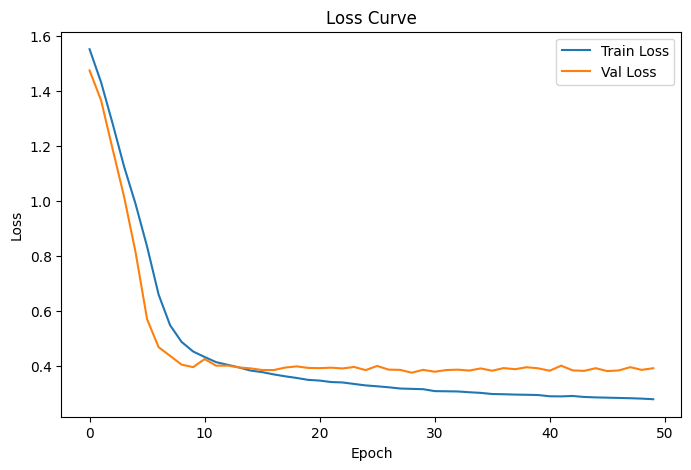

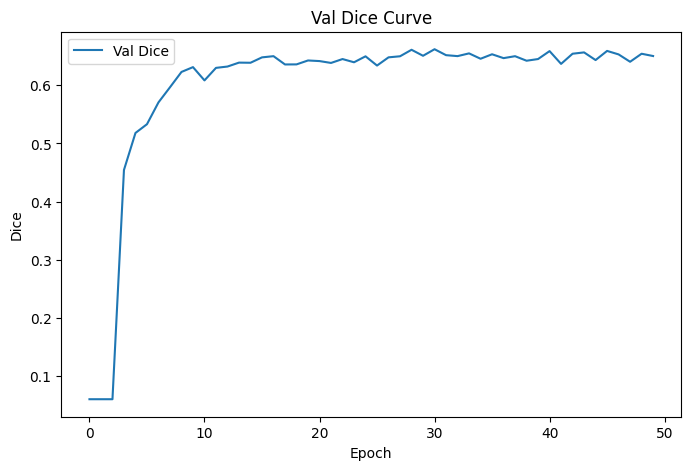

Final validation metrics:
Dice        = 0.6502299746531172
IoU         = 0.5198582896466908
Precision   = 0.6603562388208192
Recall      = 0.7606187313474359
HD95        = 93.07965113916244
HD100        = 107.70585992974176
ASSD        = 20.11238844256511
Boundary F1 = 0.5660751144163264
Metrics saved to: E:\CMU courses\2026 Spring\16725 Medical Image Analysis\final project\code\output\Unet_lr1e4_third_version\metrics.csv
Best metrics saved to: E:\CMU courses\2026 Spring\16725 Medical Image Analysis\final project\code\output\Unet_lr1e4_third_version\best_metrics.csv


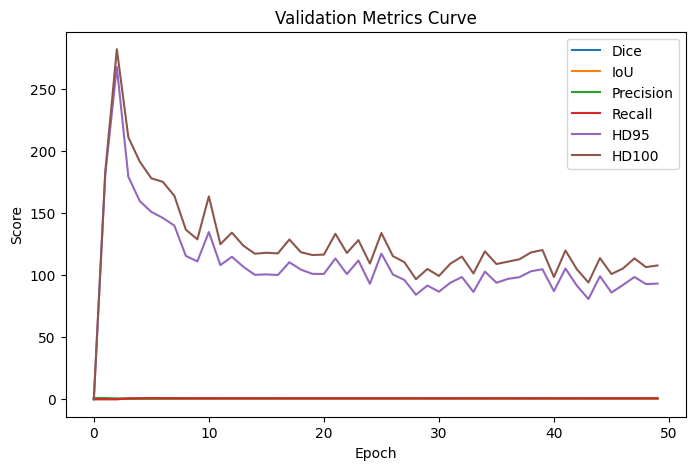

In [17]:
##Block 14 Calculate Loss and dice
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, "loss_curve.png"), dpi=300)
plt.show()
plt.figure(figsize=(8, 5))
plt.plot(val_dices, label="Val Dice")
plt.title("Val Dice Curve")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, "dice_curve.png"), dpi=300)
plt.show()
print("Final validation metrics:")
print("Dice        =", val_dices[-1])
print("IoU         =", val_ious[-1])
print("Precision   =", val_precisions[-1])
print("Recall      =", val_recalls[-1])
print("HD95        =", val_hd95s[-1])
print("HD100        =", val_hd100s[-1])
print("ASSD        =", val_assds[-1])
print("Boundary F1 =", val_bf1s[-1])

metrics_df = pd.DataFrame({
    "epoch": list(range(1, len(val_dices)+1)),
    "dice": val_dices,
    "iou": val_ious,
    "precision": val_precisions,
    "recall": val_recalls,
    "hd95": val_hd95s,
    "hd100": val_hd100s,
    "assd": val_assds,
    "boundary_f1": val_bf1s
})
csv_path = os.path.join(OUTPUT_DIR, "metrics.csv")
metrics_df.to_csv(csv_path, index=False)
print(f"Metrics saved to: {csv_path}")

best_idx = np.argmax(val_dices)
best_metrics = {
    "best_epoch": best_idx + 1,
    "dice": val_dices[best_idx],
    "iou": val_ious[best_idx],
    "precision": val_precisions[best_idx],
    "recall": val_recalls[best_idx],
    "hd95": val_hd95s[best_idx],
    "hd100": val_hd100s[best_idx],
    "assd": val_assds[best_idx],
    "boundary_f1": val_bf1s[best_idx]
}
best_df = pd.DataFrame([best_metrics])
best_path = os.path.join(OUTPUT_DIR, "best_metrics.csv")
best_df.to_csv(best_path, index=False)
print(f"Best metrics saved to: {best_path}")

plt.figure(figsize=(8, 5))
plt.plot(val_dices, label="Dice")
plt.plot(val_ious, label="IoU")
plt.plot(val_precisions, label="Precision")
plt.plot(val_recalls, label="Recall")
plt.plot(val_hd95s, label="HD95")
plt.plot(val_hd100s, label="HD100")
plt.title("Validation Metrics Curve")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.show()


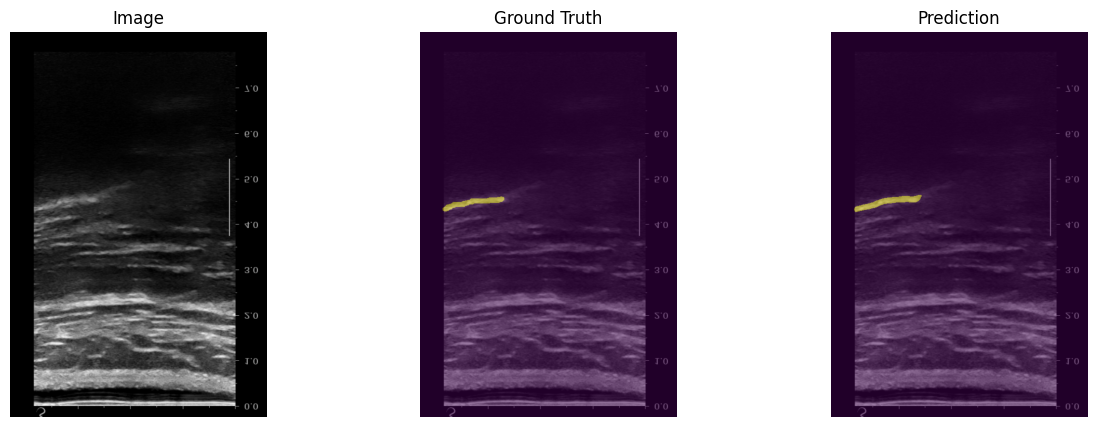

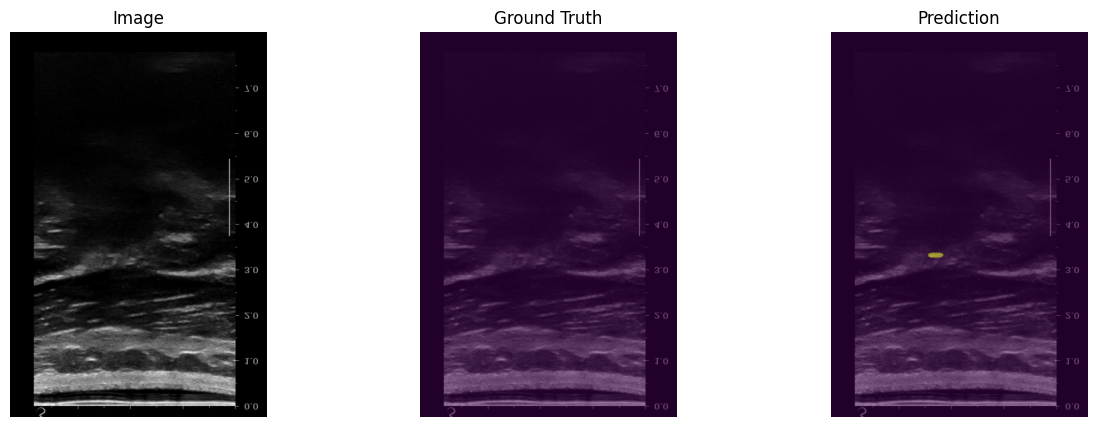

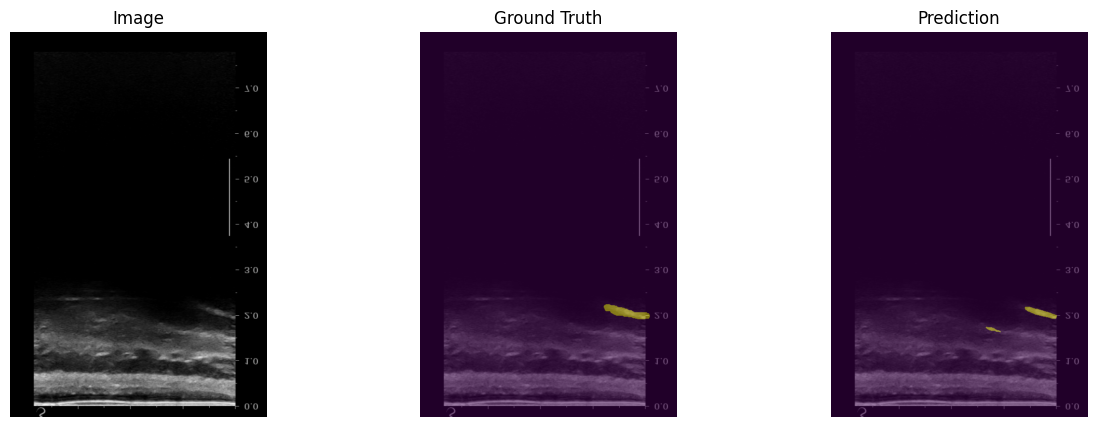

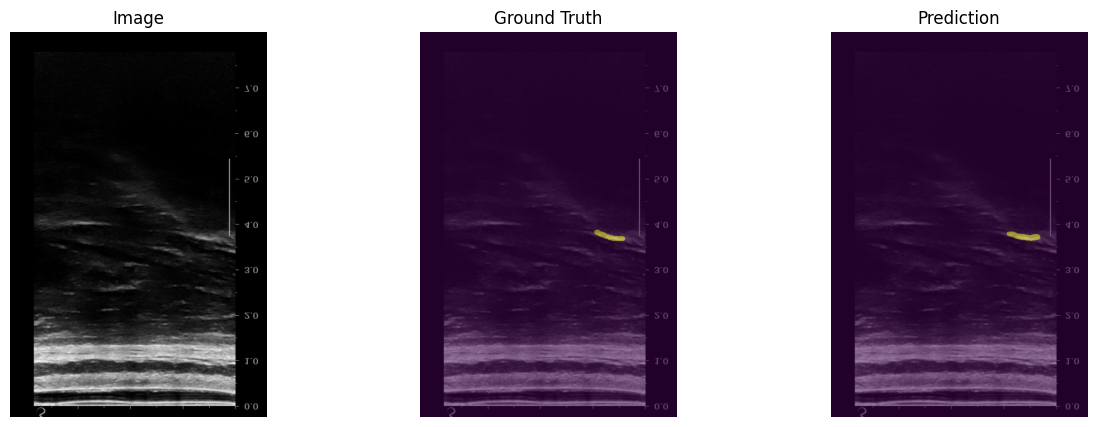

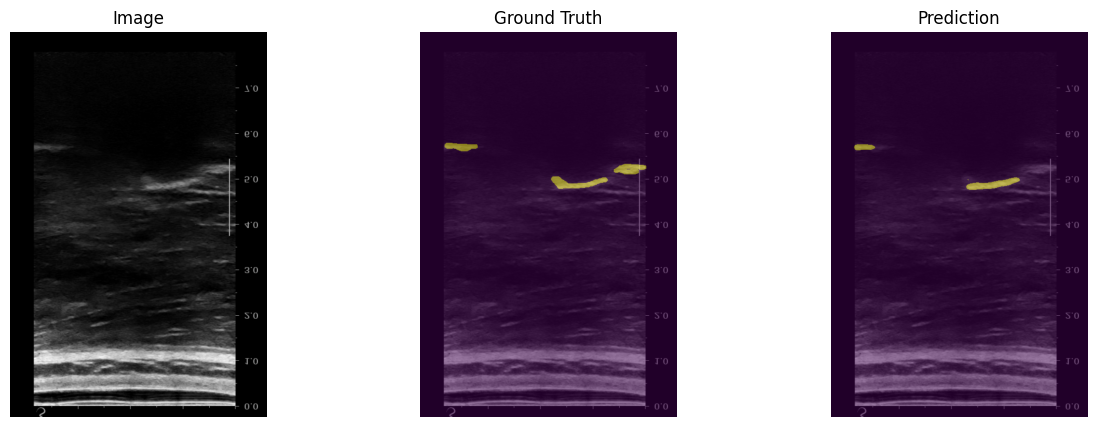

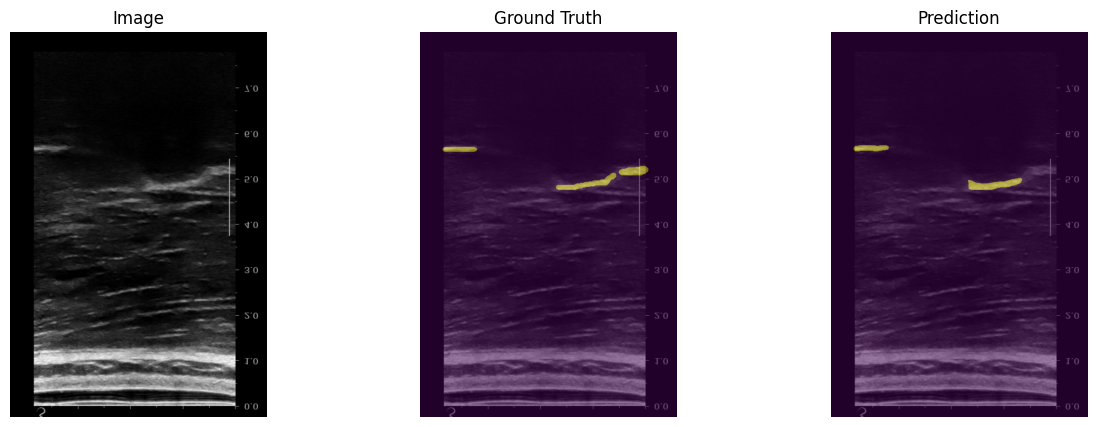

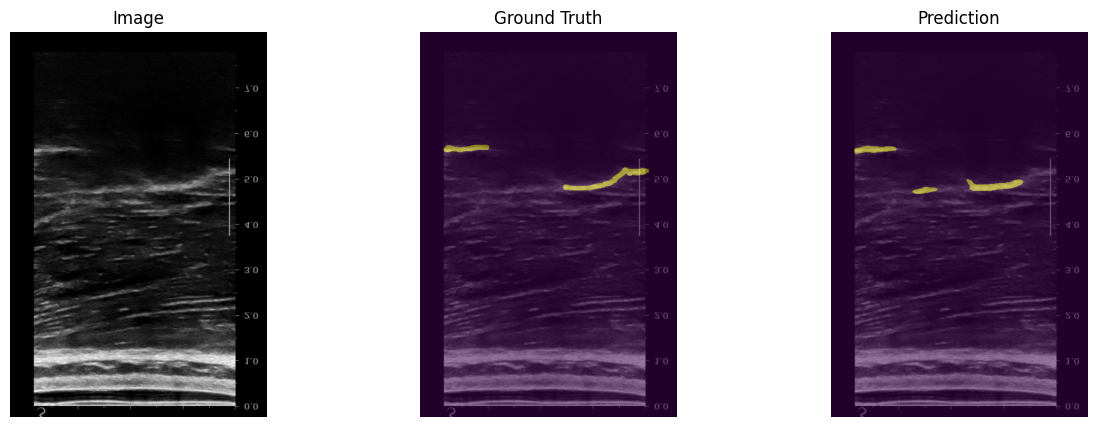

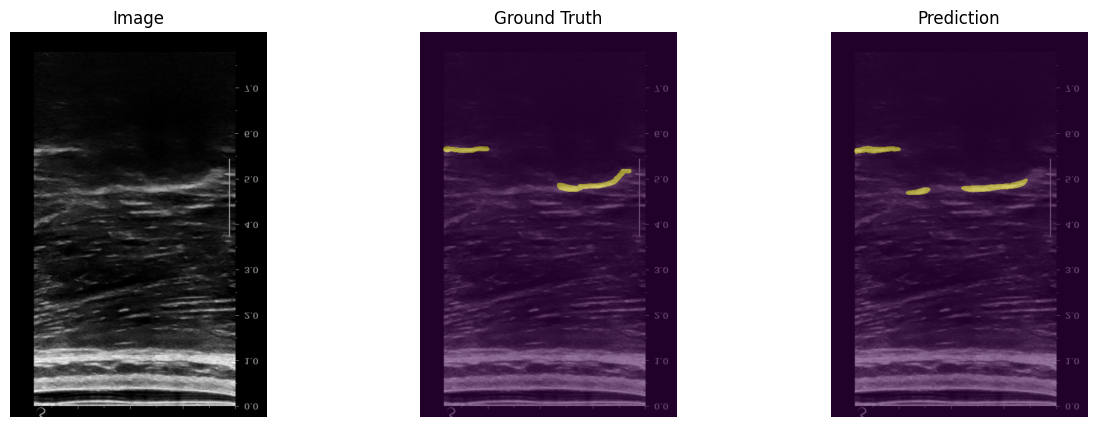

In [18]:
#Block15

model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "best_model.pt"), map_location=DEVICE))
model.eval()

saved = 0
idx=0

with torch.no_grad():
    for batch_data in val_loader:
        inputs = batch_data["image"].to(DEVICE)
        labels = batch_data["label"].to(DEVICE)

        outputs = model(inputs)
        preds = torch.sigmoid(outputs)
        preds = (preds > 0.5).float()

        for i in range(inputs.shape[0]):
            img = inputs[i, 0].cpu().numpy()
            gt = labels[i, 0].cpu().numpy()
            pd = preds[i, 0].cpu().numpy()

            fig, axes = plt.subplots(1, 3, figsize=(15, 5))

            axes[0].imshow(img, cmap="gray")
            axes[0].set_title("Image")
            axes[0].axis("off")

            axes[1].imshow(img, cmap="gray")
            axes[1].imshow(gt, alpha=0.5)
            axes[1].set_title("Ground Truth")
            axes[1].axis("off")

            axes[2].imshow(img, cmap="gray")
            axes[2].imshow(pd, alpha=0.5)
            axes[2].set_title("Prediction")
            axes[2].axis("off")
             
            save_path = os.path.join(OUTPUT_DIR, f"prediction_{idx}.png")
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            plt.show()
            idx += 1
            saved += 1
            if saved >= NUM_VIS_SAMPLES:
                break

        if saved >= NUM_VIS_SAMPLES:
            break